In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [4]:
vis_epoch_lims=(-1.0, 2.0)
mot_epoch_lims=(-1.0, 1.5)
vis_plot_lims=(-0.25, 1.85)
mot_plot_lims=(-0.7, 1.2)

In [5]:
# Set global matplotlib parameters
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

# Define color palettes
colors0 = sns.color_palette("magma", n_colors=6)
colors1 = sns.color_palette("mako_r", n_colors=10)
pastel = sns.color_palette("Pastel1", n_colors=6)
adapt1 = sns.color_palette("Set1", n_colors=9)
adapt2 = sns.color_palette("Accent", n_colors=8)
colors4 = sns.color_palette("magma_r", n_colors=4)
colors5 = sns.color_palette("mako_r", n_colors=4)

colors2 = [pastel[0], pastel[3], adapt2[5]]
colors3 = [pastel[1], pastel[2], colors5[2]]
colors_implicit = [pastel[0], adapt2[5], pastel[3]]  # Baseline, Washout, Adaptation
colors_explicit = [pastel[1], colors5[2], pastel[2]]  # Baseline, Washout, Adaptation
colorbl = [adapt1[4], colors1[2]]

# Define plot limits and proportional widths
plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
durations = {k: plot_lims[k][1] - plot_lims[k][0] for k in ['vis', 'mot']}
total_width = durations['vis'] + durations['mot']
width_ratios = [durations['vis'] / total_width, durations['mot'] / total_width]

In [6]:
def plot_var_results(var_name, disp_name):
    vis_df = pd.read_csv(f"output/PC_vis_burst_rate_{var_name}.csv")
    mot_df = pd.read_csv(f"output/PC_mot_burst_rate_{var_name}.csv")
    try:
        vis_stats = pd.read_csv(f"output/PC_vis_{var_name}_win.csv")
    except:
        vis_stats = pd.DataFrame({
            'pc': [],
            'quartile': [],
            'start': []
        })
    try:
        mot_stats = pd.read_csv(f"output/PC_mot_{var_name}_win.csv")
    except:
        mot_stats = pd.DataFrame({
            'pc': [],
            'quartile': [],
            'start': []
        })
    
    group_colors = {"Implicit": colorbl[0], "Explicit": colorbl[1]}
    pcs = [7]#, 8, 9, 10]
    quartiles = [1, 2, 3, 4]
    plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
    for pc in pcs:
        for q in quartiles:
            vis_subset = vis_df[(vis_df.pc == pc) & (vis_df.quartile == q)].copy()
            mot_subset = mot_df[(mot_df.pc == pc) & (mot_df.quartile == q)].copy()
        
            if 'dur' in var_name or 'rt' in var_name:
                vis_subset['estimate']=vis_subset['estimate']*1000
                mot_subset['estimate']=mot_subset['estimate']*1000
                vis_subset['SE']=vis_subset['SE']*1000
                mot_subset['SE']=mot_subset['SE']*1000
                
            vis_subset = vis_subset[np.isfinite(vis_subset["SE"])]
            mot_subset = mot_subset[np.isfinite(mot_subset["SE"])]
        
            y_all = pd.concat([vis_subset["estimate"], mot_subset["estimate"]])
            y_min, y_max = y_all.min(), y_all.max()
            y_span = y_max - y_min
            y_offset_unit = 0.2 * y_span
            y_exp_marker = y_max + y_offset_unit
            y_imp_marker = y_exp_marker + y_offset_unit
            y_int_marker = y_imp_marker + y_offset_unit
        
            fig = plt.figure(figsize=(10, 4))
            gs = fig.add_gridspec(1, 2, width_ratios=width_ratios)
            group_list = ["Implicit", "Explicit"]
            common_ylim = (y_min - y_offset_unit, y_int_marker + y_offset_unit)
        
            for idx, (subset, limits, title, stats_df, full_df) in zip(
                range(2),
                [(vis_subset, plot_lims['vis'], "vis", vis_stats, vis_df),
                 (mot_subset, plot_lims['mot'], "mot", mot_stats, mot_df)]
            ):
                ax = fig.add_subplot(gs[idx])
        
                q_stats_df=stats_df[(stats_df['pc']==pc) & (stats_df['quartile']==q) & (stats_df['start']>limits[0])]
                for group in group_list:
                    df_group = subset[(subset['group'] == group) & (np.isfinite(subset['SE']))].copy()
                    if df_group.empty:
                        continue
        
                    time = df_group['time'].astype(float).values
                    est = df_group['estimate'].astype(float).values
                    se = df_group['SE'].astype(float).values
        
                    ax.plot(time, est, label=group, color=group_colors[group], linewidth=2)
                    ax.fill_between(time, est - se, est + se, alpha=0.2, color=group_colors[group])
        
                interaction_idxs=np.zeros(time.shape)
        
                for index, q_stats_row in q_stats_df.iterrows():
                    start=q_stats_row['start']
                    end=q_stats_row['end']
                    chi_sq=q_stats_row['chi_sq']
                    dof=q_stats_row['df']
                    p_val=q_stats_row['p_val']
                    if q_stats_row['factor']=='group:mean_burst_count':
                        exp_onesamp_z=q_stats_row['explicit_onesamp_z']
                        exp_onesamp_p=q_stats_row['explicit_onesamp_p']
                        imp_onesamp_z=q_stats_row['implicit_onesamp_z']
                        imp_onesamp_p=q_stats_row['implicit_onesamp_p']
                        explicit_implicit_z=q_stats_row['explicit_implicit_z']
                        explicit_implicit_p=q_stats_row['explicit_implicit_p']
                        
                        print(f'{title} PC{pc} Q{q}: group:mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                        print(f'                     explicit: z = {exp_onesamp_z}, p = {exp_onesamp_p}')
                        print(f'                     implicit: z = {imp_onesamp_z}, p = {imp_onesamp_p}')
                        print(f'                     explicit - implicit: z = {explicit_implicit_z}, p = {explicit_implicit_p}')
                        
                        t_idx=np.where((time>=start) & (time<end))[0]
                        if exp_onesamp_p<0.05:
                            ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                       color=group_colors['Explicit'], marker="*", s=80, zorder=10)
                        if imp_onesamp_p<0.05:
                            ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                       color=group_colors['Implicit'], marker="*", s=80, zorder=10)
                        if explicit_implicit_p<0.05:
                            ax.scatter(time[t_idx], [y_int_marker] * len(t_idx),
                                       color='r', marker="*", s=80, zorder=10)
                        interaction_idxs[t_idx]=True
                        
                for index, q_stats_row in q_stats_df.iterrows():
                    start=q_stats_row['start']
                    end=q_stats_row['end']
                    chi_sq=q_stats_row['chi_sq']
                    dof=q_stats_row['df']
                    p_val=q_stats_row['p_val']
                    if q_stats_row['factor']=='mean_burst_count':
                        print(f'{title} PC{pc} Q{q}: mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                        t_idx=np.where((time>=start) & (time<end) & (interaction_idxs==0))[0]
                        ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                   color=group_colors['Explicit'], marker="*", s=80, zorder=10)  
                        ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                       color=group_colors['Implicit'], marker="*", s=80, zorder=10)
                        
                ax.axhline(0, linestyle="--", color="black", linewidth=1)
                ax.set_ylim(*common_ylim)
                ax.set_title(f"{title.upper()}")
                ax.set_xlabel("Time (s)")
                if idx == 0:
                    ax.set_ylabel(f"{disp_name} effect")
                else:
                    ax.set_yticklabels([])
                ax.set_xlim(limits)
        
            handles, labels = ax.get_legend_handles_labels()
            fig.legend(handles, labels)
            fig.suptitle(f"{disp_name} - PC {pc}, Quartile {q}")
            plt.tight_layout()
            # plt.savefig(os.path.join('./output/burst_behav_results',f'PC{pc}_Q{q}_{var_name}.pdf'))
            plt.show()

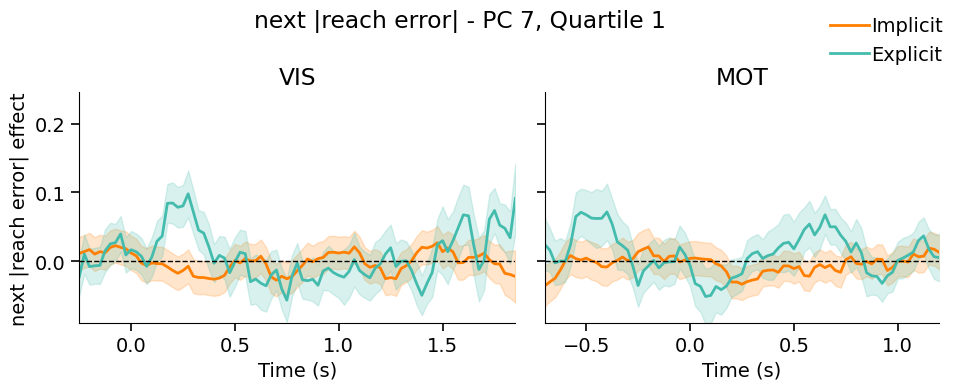

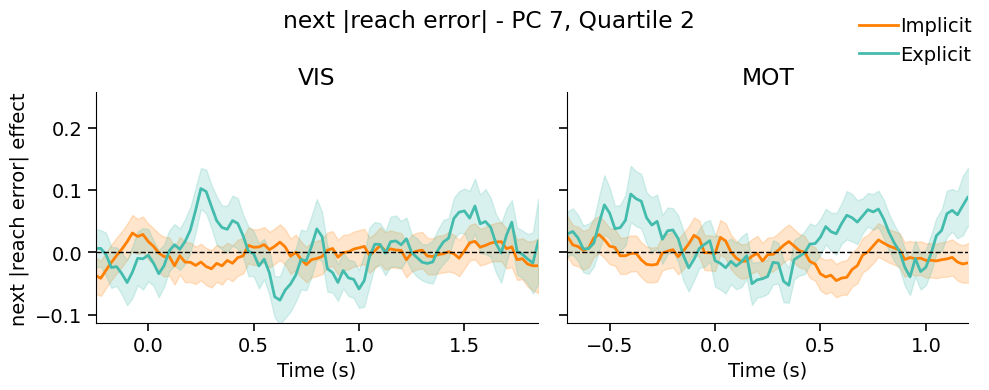

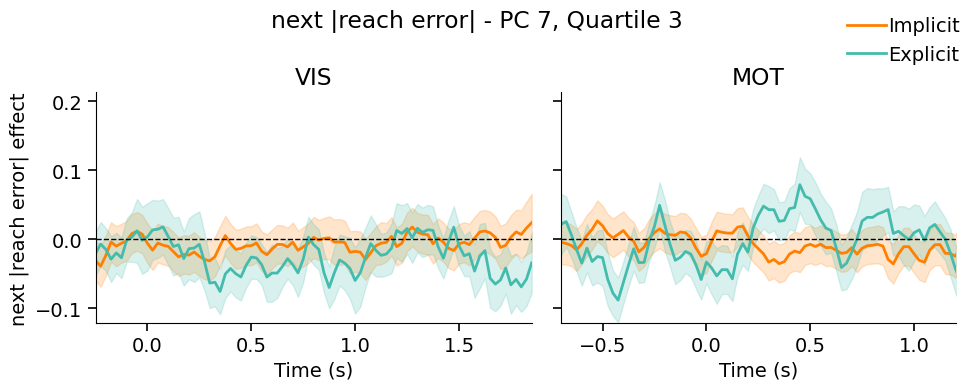

vis PC7 Q4: mean_burst_count 0.05-0.45s, ChiSq(1)=5.85265631802534, p = 0.0155535568769598
mot PC7 Q4: group:mean_burst_count 0.35-0.775s, ChiSq(1)=8.510123609091721, p = 0.0035317607086114
                     explicit: z = -2.9623298208908686, p = 0.0030532053598143
                     implicit: z = 0.678712446371684, p = 0.497320078375197
                     explicit - implicit: z = -2.917211615411491, p = 0.0035317607086114
mot PC7 Q4: mean_burst_count 0.35-0.775s, ChiSq(1)=5.131556816562359, p = 0.0234946452155068


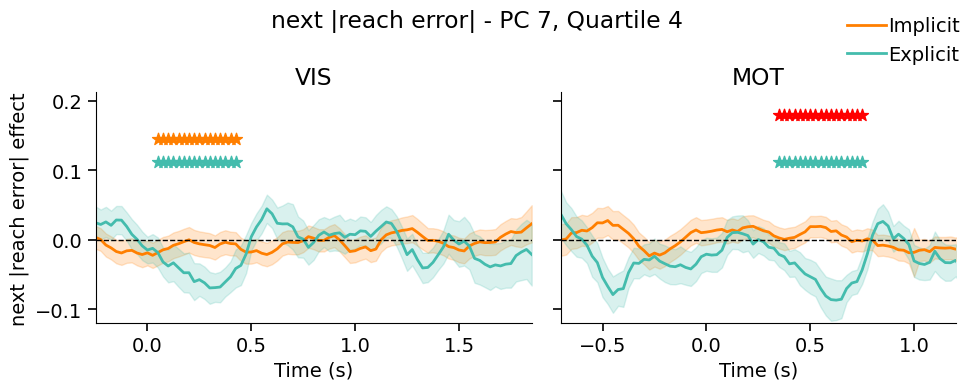

In [7]:
plot_var_results('reach_vis_abs_err_next_trial', 'next |reach error|')

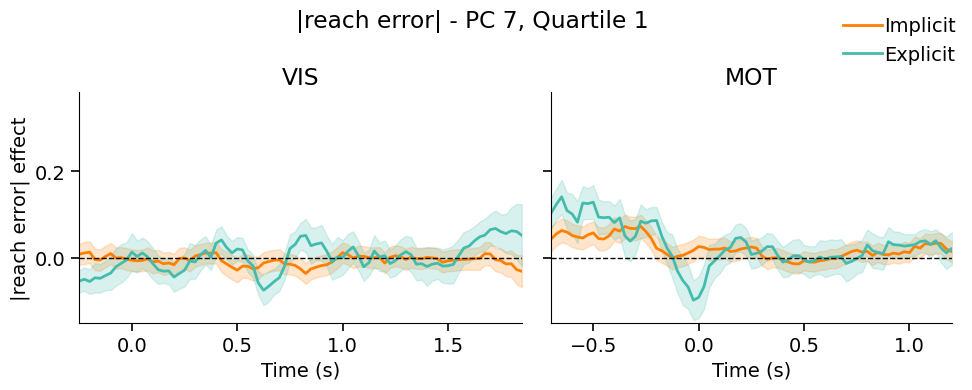

mot PC7 Q2: mean_burst_count 0.025-1.35s, ChiSq(1)=28.73331154110297, p = 8.306261027447529e-08


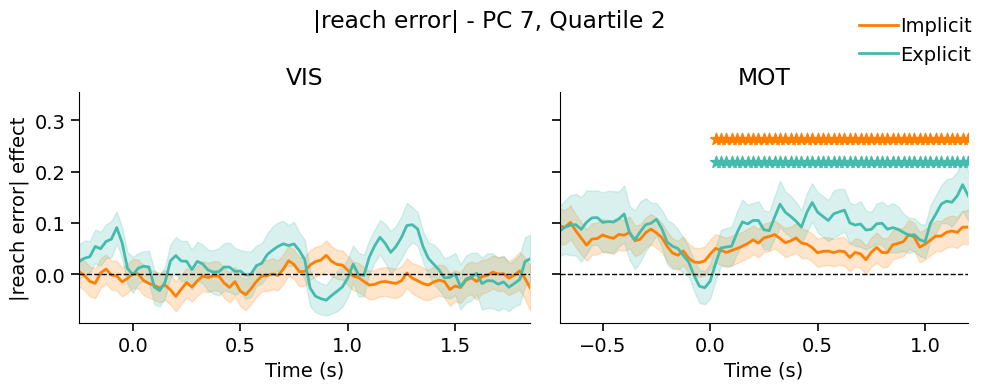

mot PC7 Q3: group:mean_burst_count 0.275-1.15s, ChiSq(1)=9.07368959611276, p = 0.0025931333026661
                     explicit: z = 4.719108971227209, p = 2.368799099108588e-06
                     implicit: z = 2.053634283188188, p = 0.0400111014009312
                     explicit - implicit: z = 3.0122565621329067, p = 0.0025931333026661


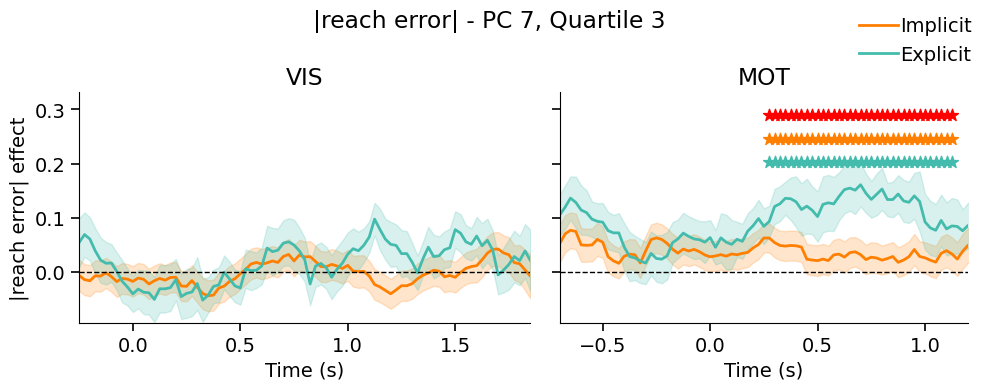

mot PC7 Q4: group:mean_burst_count 0.425-1.175s, ChiSq(1)=7.313074941470541, p = 0.006845469054925
                     explicit: z = -5.663571653894755, p = 1.4825422035787504e-08
                     implicit: z = -3.721391786132268, p = 0.00019812776750017703
                     explicit - implicit: z = -2.704269761224005, p = 0.006845469054925
mot PC7 Q4: mean_burst_count 0.075-1.35s, ChiSq(1)=35.97305028249291, p = 2.000655696811064e-09


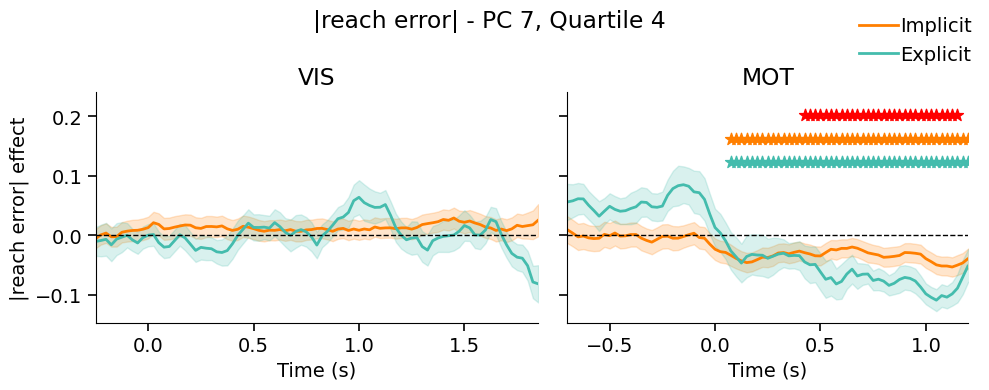

In [8]:
plot_var_results('reach_vis_abs_err', '|reach error|')

mot PC7 Q1: group:mean_burst_count 0.45-0.825s, ChiSq(1)=7.221657321916436, p = 0.0072029174140582
                     explicit: z = 2.2924851158241992, p = 0.0218776654604454
                     implicit: z = -1.4033703316450783, p = 0.1605064352841454
                     explicit - implicit: z = 2.6873141464883545, p = 0.0072029174140582


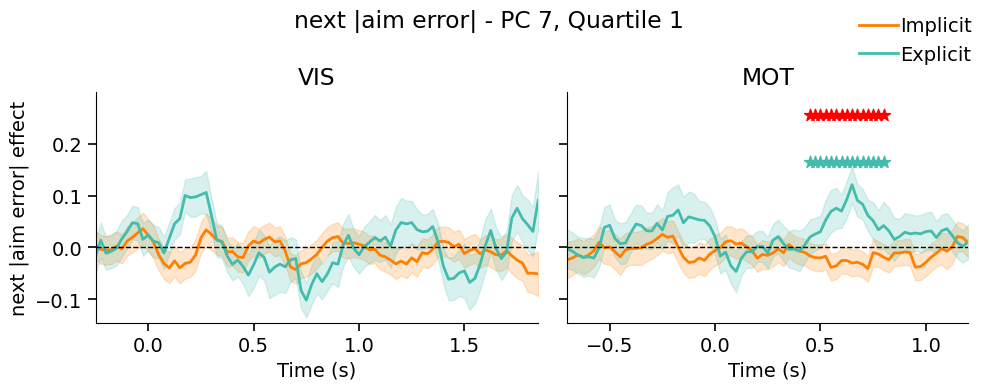

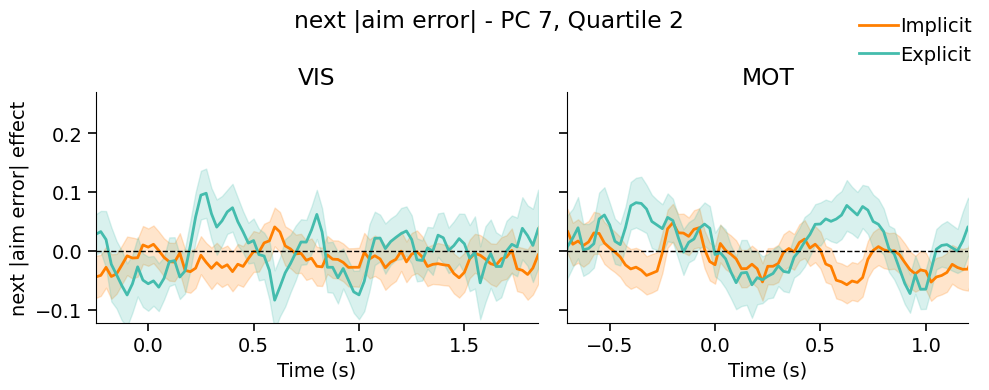

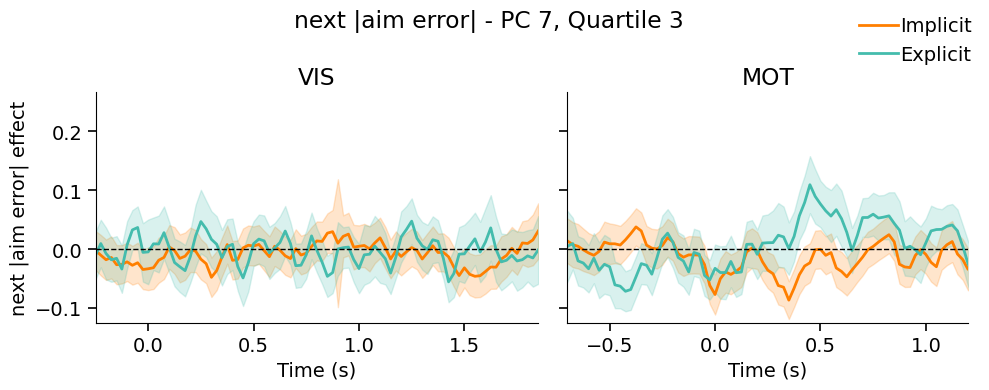

mot PC7 Q4: group:mean_burst_count 0.35-0.75s, ChiSq(1)=5.706020707114123, p = 0.016906821430955
                     explicit: z = -2.7266501489645694, p = 0.0063980835797988
                     implicit: z = 0.3200622383644725, p = 0.7489211505431512
                     explicit - implicit: z = -2.388727842830598, p = 0.0169068214309551
mot PC7 Q4: mean_burst_count 0.325-0.775s, ChiSq(1)=3.948572411245178, p = 0.0469111489496116


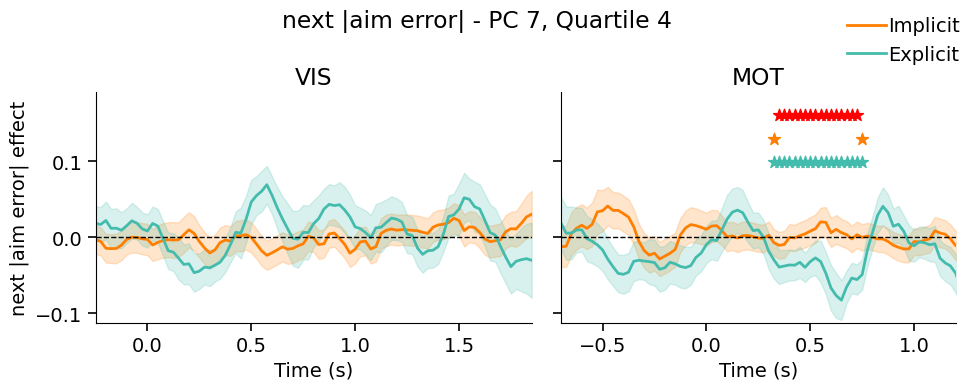

In [9]:
plot_var_results('aim_vis_abs_err_next_trial', 'next |aim error|')

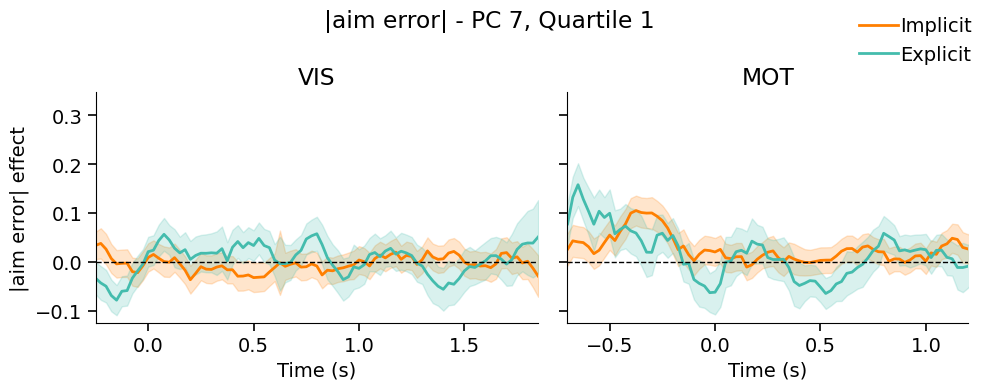

mot PC7 Q2: mean_burst_count 0.7-1.275s, ChiSq(1)=7.904935369137433, p = 0.0049300102995957


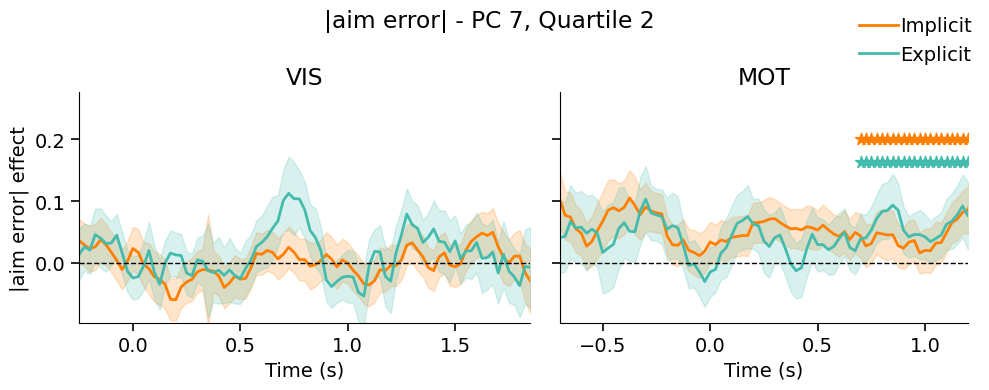

mot PC7 Q3: mean_burst_count -0.075-1.0s, ChiSq(1)=18.96475184415557, p = 1.33155741847692e-05


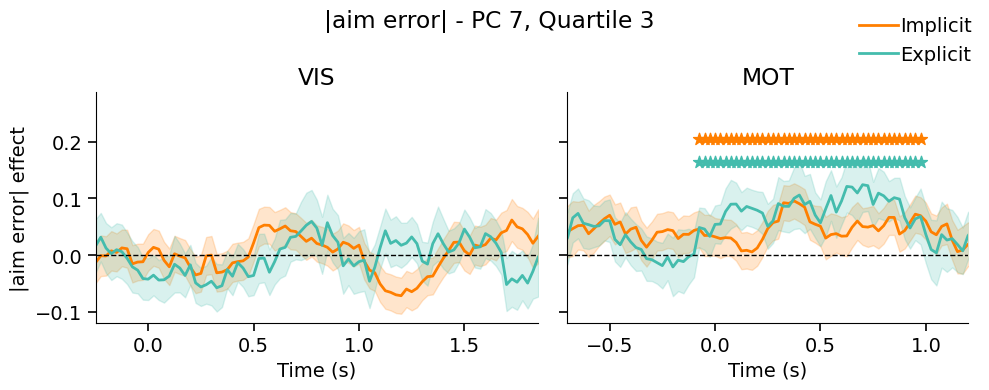

mot PC7 Q4: mean_burst_count 0.5-1.325s, ChiSq(1)=32.859411124599035, p = 9.907029512075216e-09


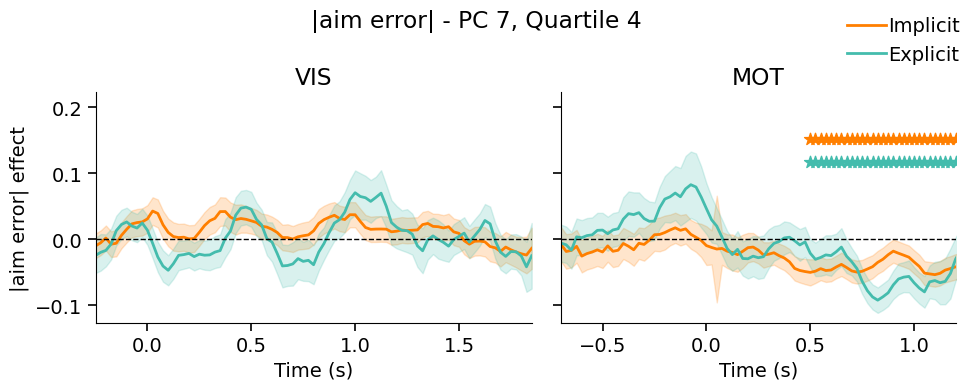

In [10]:
plot_var_results('aim_vis_abs_err', '|aim error|')

vis PC7 Q1: group:mean_burst_count 0.575-1.475s, ChiSq(1)=8.960867369619924, p = 0.0027582391011521
                     explicit: z = -2.427910807808699, p = 0.0151860774185289
                     implicit: z = 1.8762615356582693, p = 0.0606193759941855
                     explicit - implicit: z = -2.9934707898391, p = 0.0027582391011521


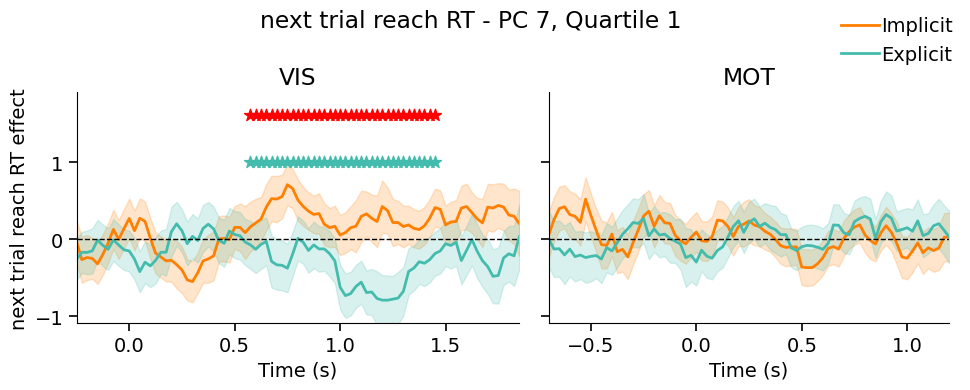

vis PC7 Q2: group:mean_burst_count 1.025-1.45s, ChiSq(1)=6.5745398958083925, p = 0.0103447741537951
                     explicit: z = -2.867783971150311, p = 0.0041335766920063
                     implicit: z = 0.861101795776646, p = 0.3891819802397445
                     explicit - implicit: z = -2.5640865616839834, p = 0.0103447741537951


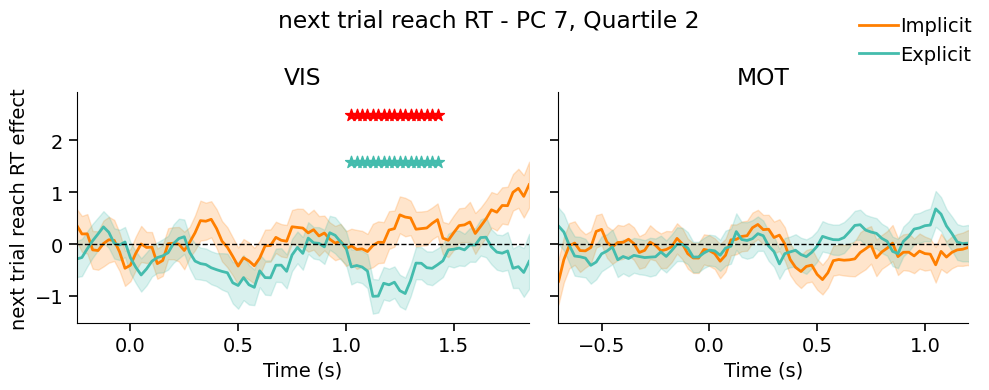

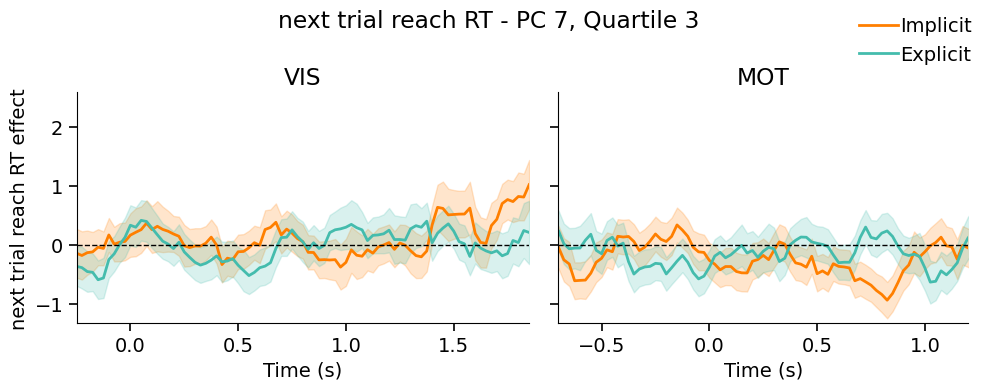

vis PC7 Q4: mean_burst_count 1.025-1.4s, ChiSq(1)=7.034990529631163, p = 0.0079932296317963


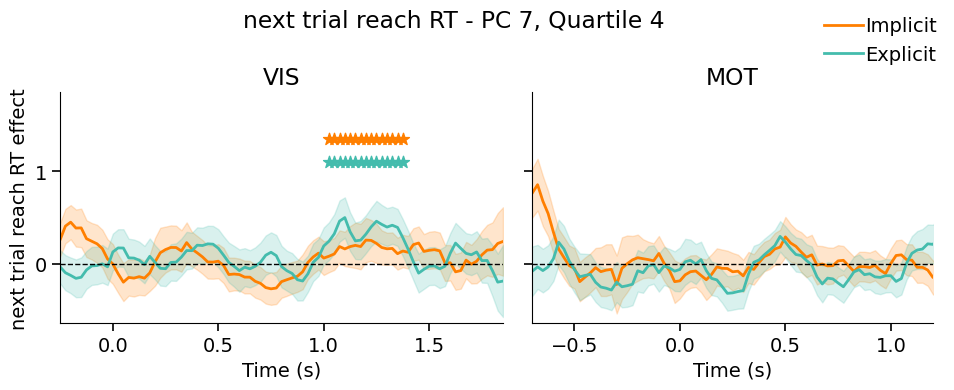

In [11]:
plot_var_results('reach_rt_next_trial', 'next trial reach RT')

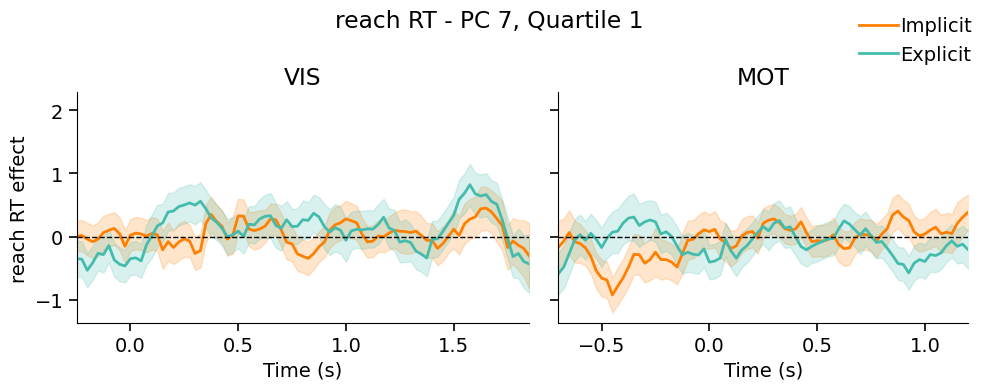

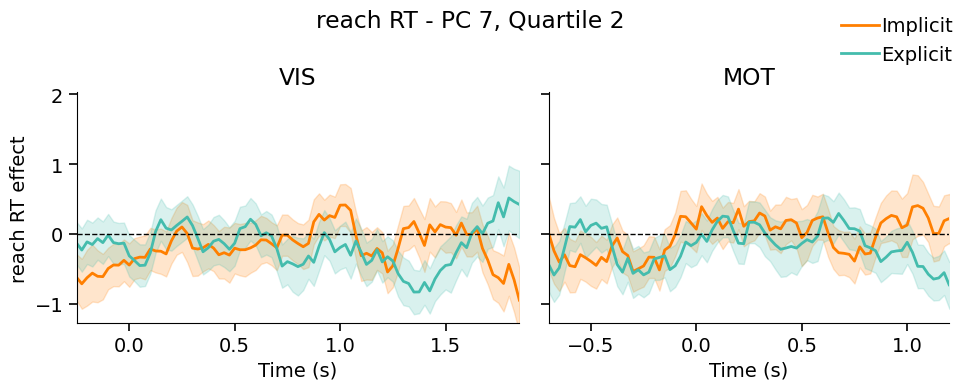

mot PC7 Q3: group:mean_burst_count -0.525--0.1s, ChiSq(1)=5.412581597974766, p = 0.0199921289745278
                     explicit: z = -1.0558262658442172, p = 0.2910475958324898
                     implicit: z = 2.1070868414062, p = 0.0351100527250966
                     explicit - implicit: z = -2.326495561563522, p = 0.0199921289745278


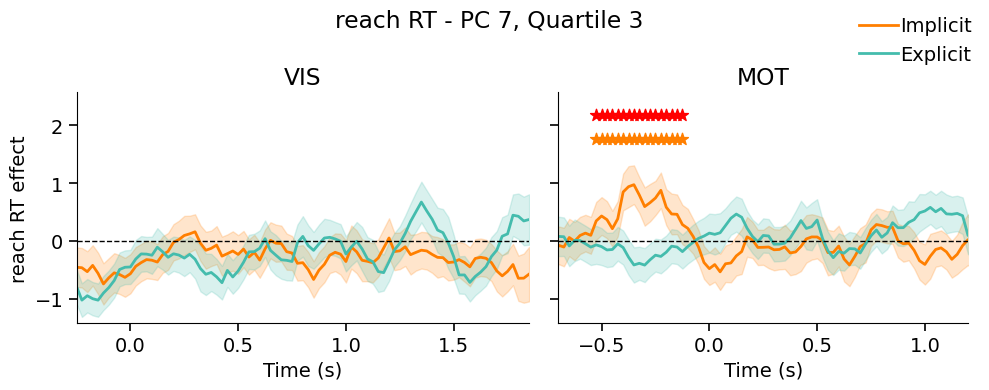

mot PC7 Q4: group:mean_burst_count 0.9-1.35s, ChiSq(1)=6.2414829818635456, p = 0.0124791939388034
                     explicit: z = 1.4289197376676368, p = 0.1530273037324046
                     implicit: z = -2.088095978532684, p = 0.0367891777464588
                     explicit - implicit: z = 2.4982960156601832, p = 0.0124791939388034


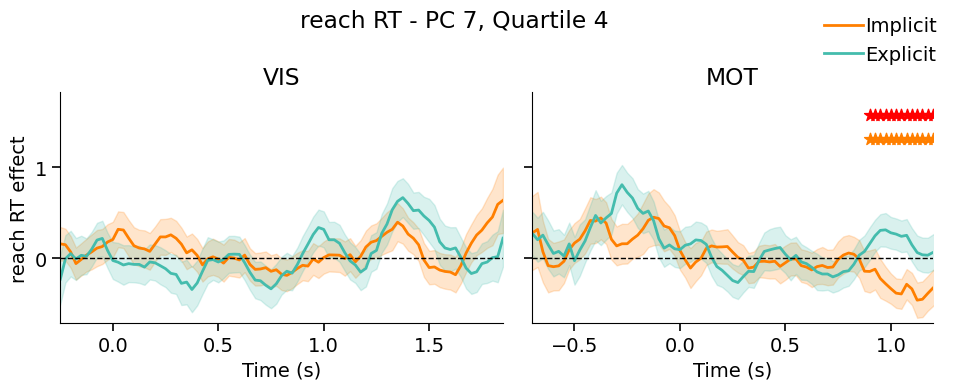

In [12]:
plot_var_results('reach_rt', 'reach RT')

mot PC7 Q1: group:mean_burst_count 0.25-0.8s, ChiSq(1)=4.359427831979458, p = 0.0368046648823349
                     explicit: z = -1.5276937442226366, p = 0.1265885940582821
                     implicit: z = 1.4226433370938425, p = 0.154839574280563
                     explicit - implicit: z = -2.0879242878944284, p = 0.0368046648823348


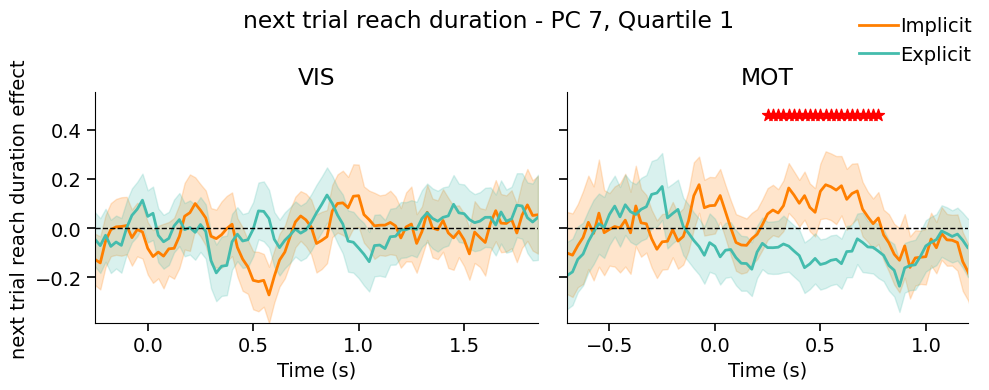

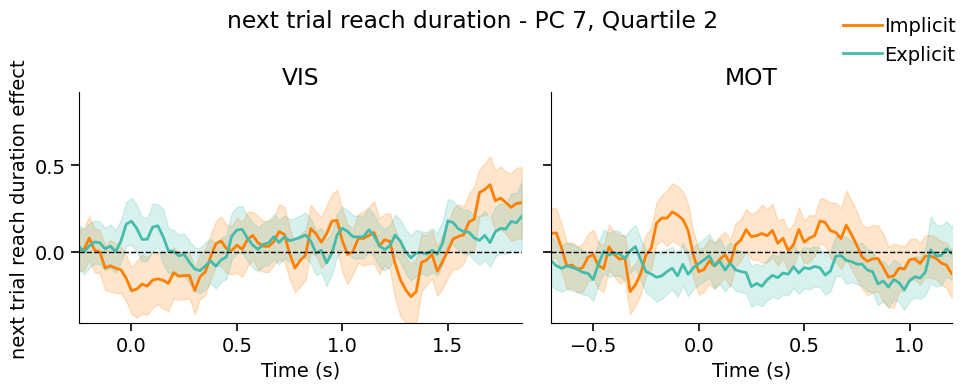

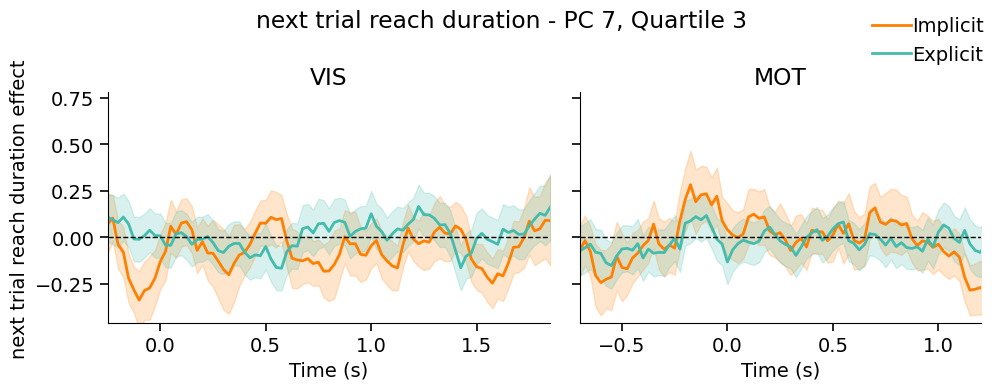

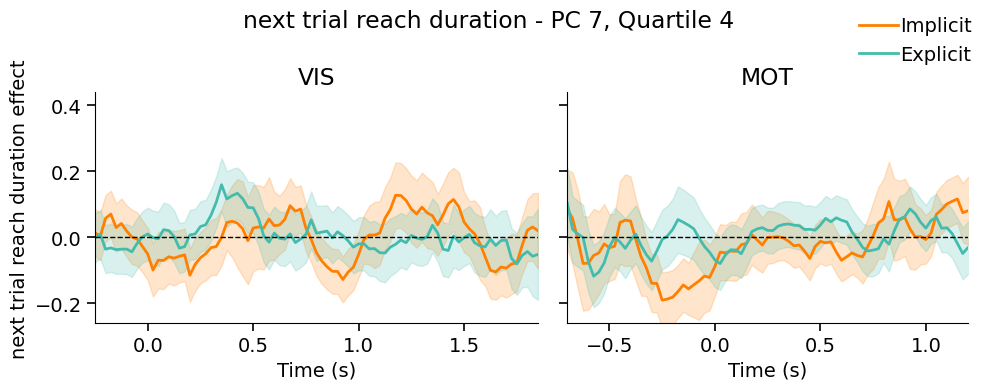

In [13]:
plot_var_results('reach_dur_next_trial', 'next trial reach duration')

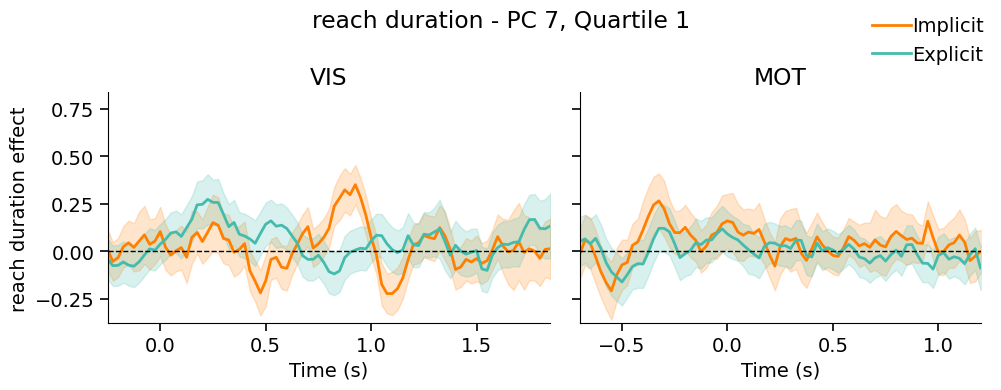

mot PC7 Q2: group:mean_burst_count 0.2-0.7s, ChiSq(1)=7.229627441323591, p = 0.0071710087414287
                     explicit: z = -0.4391021690347404, p = 0.660587507516294
                     implicit: z = 3.4670082722964897, p = 0.0005262856930896657
                     explicit - implicit: z = -2.6887966530259573, p = 0.0071710087414287


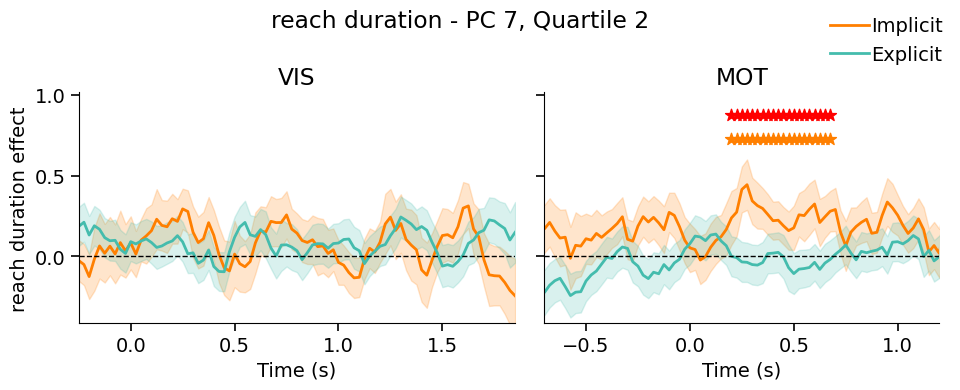

mot PC7 Q3: group:mean_burst_count -0.625--0.275s, ChiSq(1)=3.948068521866828, p = 0.0469251988154872
                     explicit: z = -0.5869913500352179, p = 0.5572095161426309
                     implicit: z = 2.0535009408171985, p = 0.0400240185875382
                     explicit - implicit: z = -1.9869747159606304, p = 0.0469251988154874


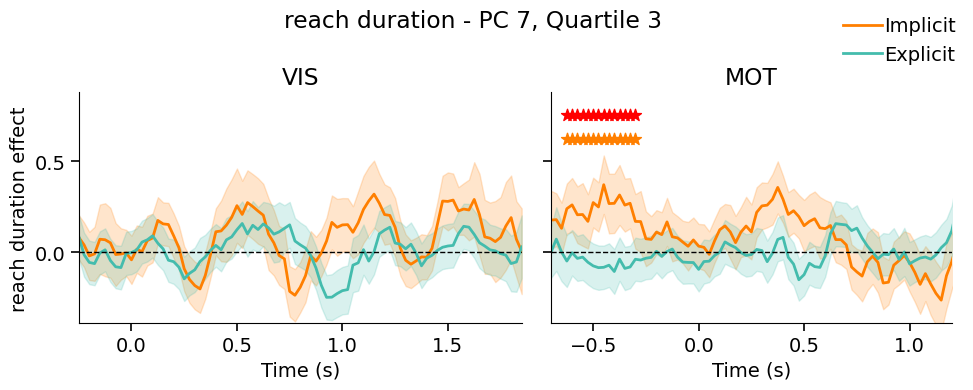

mot PC7 Q4: group:mean_burst_count 0.25-0.9s, ChiSq(1)=10.99083990735766, p = 0.0009156330623603918
                     explicit: z = 0.4805616545503294, p = 0.6308280739580587
                     implicit: z = -4.329096954096057, p = 1.4972201277481674e-05
                     explicit - implicit: z = 3.3152435668224527, p = 0.0009156330623603934


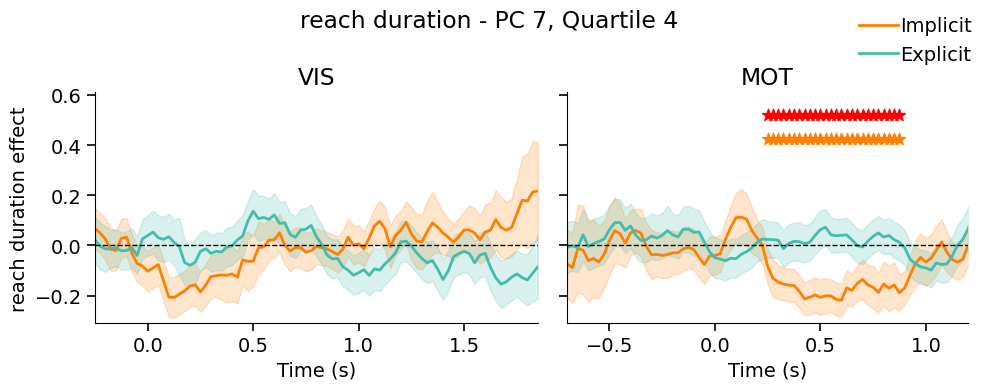

In [14]:
plot_var_results('reach_dur', 'reach duration')

In [15]:
def plot_all_vars_per_quartile(var_disp_list):
    group_colors = {"Implicit": colorbl[0], "Explicit": colorbl[1]}
    pcs = [7]
    quartiles = [1, 2, 3, 4]
    plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
    min_cluster_size = 15
    full_width_ratios = width_ratios * 2  # visual, motor × current, next

    current_vars = [(v, d) for v, d in var_disp_list if "next" not in v]
    next_vars = [(v, d) for v, d in var_disp_list if "next" in v]
    assert len(current_vars) == len(next_vars), "Mismatched number of current and next trial variables"

    for pc in pcs:
        for q in quartiles:
            fig, axes = plt.subplots(len(current_vars), 4, figsize=(16, 4 * len(current_vars)),
                                     gridspec_kw={'width_ratios': full_width_ratios})
            if len(current_vars) == 1:
                axes = np.expand_dims(axes, 0)

            for row_idx, ((curr_var, curr_disp), (next_var, next_disp)) in enumerate(zip(current_vars, next_vars)):
                for col_block, (var_name, disp_name) in enumerate([(curr_var, curr_disp), (next_var, next_disp)]):
                    vis_df = pd.read_csv(f"output/PC_vis_burst_rate_{var_name}.csv")
                    mot_df = pd.read_csv(f"output/PC_mot_burst_rate_{var_name}.csv")
                    try:
                        vis_stats = pd.read_csv(f"output/PC_vis_{var_name}_win.csv")
                    except:
                        vis_stats = pd.DataFrame({
                            'pc': [],
                            'quartile': [],
                            'start': []
                        })
                    try:
                        mot_stats = pd.read_csv(f"output/PC_mot_{var_name}_win.csv")
                    except:
                        mot_stats = pd.DataFrame({
                            'pc': [],
                            'quartile': [],
                            'start': []
                        })

                    vis_subset = vis_df[(vis_df.pc == pc) & (vis_df.quartile == q)].copy()
                    mot_subset = mot_df[(mot_df.pc == pc) & (mot_df.quartile == q)].copy()

                    if 'dur' in var_name or 'rt' in var_name:
                        vis_subset['estimate'] *= 1000
                        mot_subset['estimate'] *= 1000
                        vis_subset['SE'] *= 1000
                        mot_subset['SE'] *= 1000

                    vis_subset = vis_subset[np.isfinite(vis_subset["SE"])]
                    mot_subset = mot_subset[np.isfinite(mot_subset["SE"])]

                    y_all = pd.concat([vis_subset["estimate"], mot_subset["estimate"]])
                    y_min, y_max = y_all.min(), y_all.max()
                    y_span = y_max - y_min
                    y_offset_unit = 0.2 * y_span
                    y_exp_marker = y_max + y_offset_unit
                    y_imp_marker = y_exp_marker + y_offset_unit
                    y_int_marker = y_imp_marker + y_offset_unit
                    common_ylim = (y_min - y_offset_unit, y_int_marker + y_offset_unit)

                    for idx, (subset, limits, title, stats_df, full_df) in enumerate([
                        (vis_subset, plot_lims['vis'], "vis", vis_stats, vis_df),
                        (mot_subset, plot_lims['mot'], "mot", mot_stats, mot_df)
                    ]):
                        col_idx = col_block * 2 + idx
                        ax = axes[row_idx, col_idx]

                        q_stats_df=stats_df[(stats_df['pc']==pc) & (stats_df['quartile']==q) & (stats_df['start']>limits[0])]
                
                        for group in group_colors:
                            df_group = subset[(subset['group'] == group) & (np.isfinite(subset['SE']))].copy()
                            if df_group.empty:
                                continue
                            time = df_group['time'].astype(float).values
                            est = df_group['estimate'].astype(float).values
                            se = df_group['SE'].astype(float).values
                            ax.plot(time, est, label=group, color=group_colors[group], linewidth=2)
                            ax.fill_between(time, est - se, est + se, alpha=0.2, color=group_colors[group])

                        interaction_idxs=np.zeros(time.shape)
        
                        for index, q_stats_row in q_stats_df.iterrows():
                            start=q_stats_row['start']
                            end=q_stats_row['end']
                            chi_sq=q_stats_row['chi_sq']
                            dof=q_stats_row['df']
                            p_val=q_stats_row['p_val']
                            if q_stats_row['factor']=='group:mean_burst_count':
                                exp_onesamp_z=q_stats_row['explicit_onesamp_z']
                                exp_onesamp_p=q_stats_row['explicit_onesamp_p']
                                imp_onesamp_z=q_stats_row['implicit_onesamp_z']
                                imp_onesamp_p=q_stats_row['implicit_onesamp_p']
                                explicit_implicit_z=q_stats_row['explicit_implicit_z']
                                explicit_implicit_p=q_stats_row['explicit_implicit_p']
                                
                                print(f'{title} PC{pc} Q{q}: {var_name} ~ group:mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                                print(f'                     explicit: z = {exp_onesamp_z}, p = {exp_onesamp_p}')
                                print(f'                     implicit: z = {imp_onesamp_z}, p = {imp_onesamp_p}')
                                print(f'                     explicit - implicit: z = {explicit_implicit_z}, p = {explicit_implicit_p}')
                                
                                t_idx=np.where((time>=start) & (time<end))[0]
                                if exp_onesamp_p<0.05:
                                    ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                               color=group_colors['Explicit'], marker="*", s=80, zorder=10)
                                if imp_onesamp_p<0.05:
                                    ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                               color=group_colors['Implicit'], marker="*", s=80, zorder=10)
                                if explicit_implicit_p<0.05:
                                    ax.scatter(time[t_idx], [y_int_marker] * len(t_idx),
                                               color='r', marker="*", s=80, zorder=10)
                                interaction_idxs[t_idx]=True
                                
                        for index, q_stats_row in q_stats_df.iterrows():
                            start=q_stats_row['start']
                            end=q_stats_row['end']
                            chi_sq=q_stats_row['chi_sq']
                            dof=q_stats_row['df']
                            p_val=q_stats_row['p_val']
                            if q_stats_row['factor']=='mean_burst_count':
                                print(f'{title} PC{pc} Q{q}: {var_name} ~ mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                                t_idx=np.where((time>=start) & (time<end) & (interaction_idxs==0))[0]
                                ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                           color=group_colors['Explicit'], marker="*", s=80, zorder=10)  
                                ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                               color=group_colors['Implicit'], marker="*", s=80, zorder=10)

                        ax.axhline(0, linestyle="--", color="black", linewidth=1)
                        ax.set_ylim(*common_ylim)
                        ax.set_xlim(limits)
                        ax.set_title(f"{title.upper()}: {disp_name}")
                        if idx == 0:
                            ax.set_ylabel("Effect size")
                        else:
                            ax.set_yticklabels([])
                        ax.set_xlabel("Time (s)")

            handles, labels = axes[0, 0].get_legend_handles_labels()
            axes[0, 0].legend(handles, labels, loc="upper left", frameon=False)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            # plt.savefig(os.path.join('./output/burst_behav_results', f'PC{pc}_Q{q}_allvars.pdf'))
            plt.show()



var_disp_list = [
    ('aim_vis_abs_err', '|aim error|'),
    ('aim_vis_abs_err_next_trial', 'next |aim error|'),
    ('reach_vis_abs_err', '|reach error|'),
    ('reach_vis_abs_err_next_trial', 'next |reach error|'),
    ('reach_rt', 'reach RT'),
    ('reach_rt_next_trial', 'next trial reach RT'),
    ('reach_dur', 'reach duration'),
    ('reach_dur_next_trial', 'next trial reach duration')
]


mot PC7 Q1: aim_vis_abs_err_next_trial ~ group:mean_burst_count 0.45-0.825s, ChiSq(1)=7.221657321916436, p = 0.0072029174140582
                     explicit: z = 2.2924851158241992, p = 0.0218776654604454
                     implicit: z = -1.4033703316450783, p = 0.1605064352841454
                     explicit - implicit: z = 2.6873141464883545, p = 0.0072029174140582
vis PC7 Q1: reach_rt_next_trial ~ group:mean_burst_count 0.575-1.475s, ChiSq(1)=8.960867369619924, p = 0.0027582391011521
                     explicit: z = -2.427910807808699, p = 0.0151860774185289
                     implicit: z = 1.8762615356582693, p = 0.0606193759941855
                     explicit - implicit: z = -2.9934707898391, p = 0.0027582391011521
mot PC7 Q1: reach_dur_next_trial ~ group:mean_burst_count 0.25-0.8s, ChiSq(1)=4.359427831979458, p = 0.0368046648823349
                     explicit: z = -1.5276937442226366, p = 0.1265885940582821
                     implicit: z = 1.4226433370938425, p = 0.1

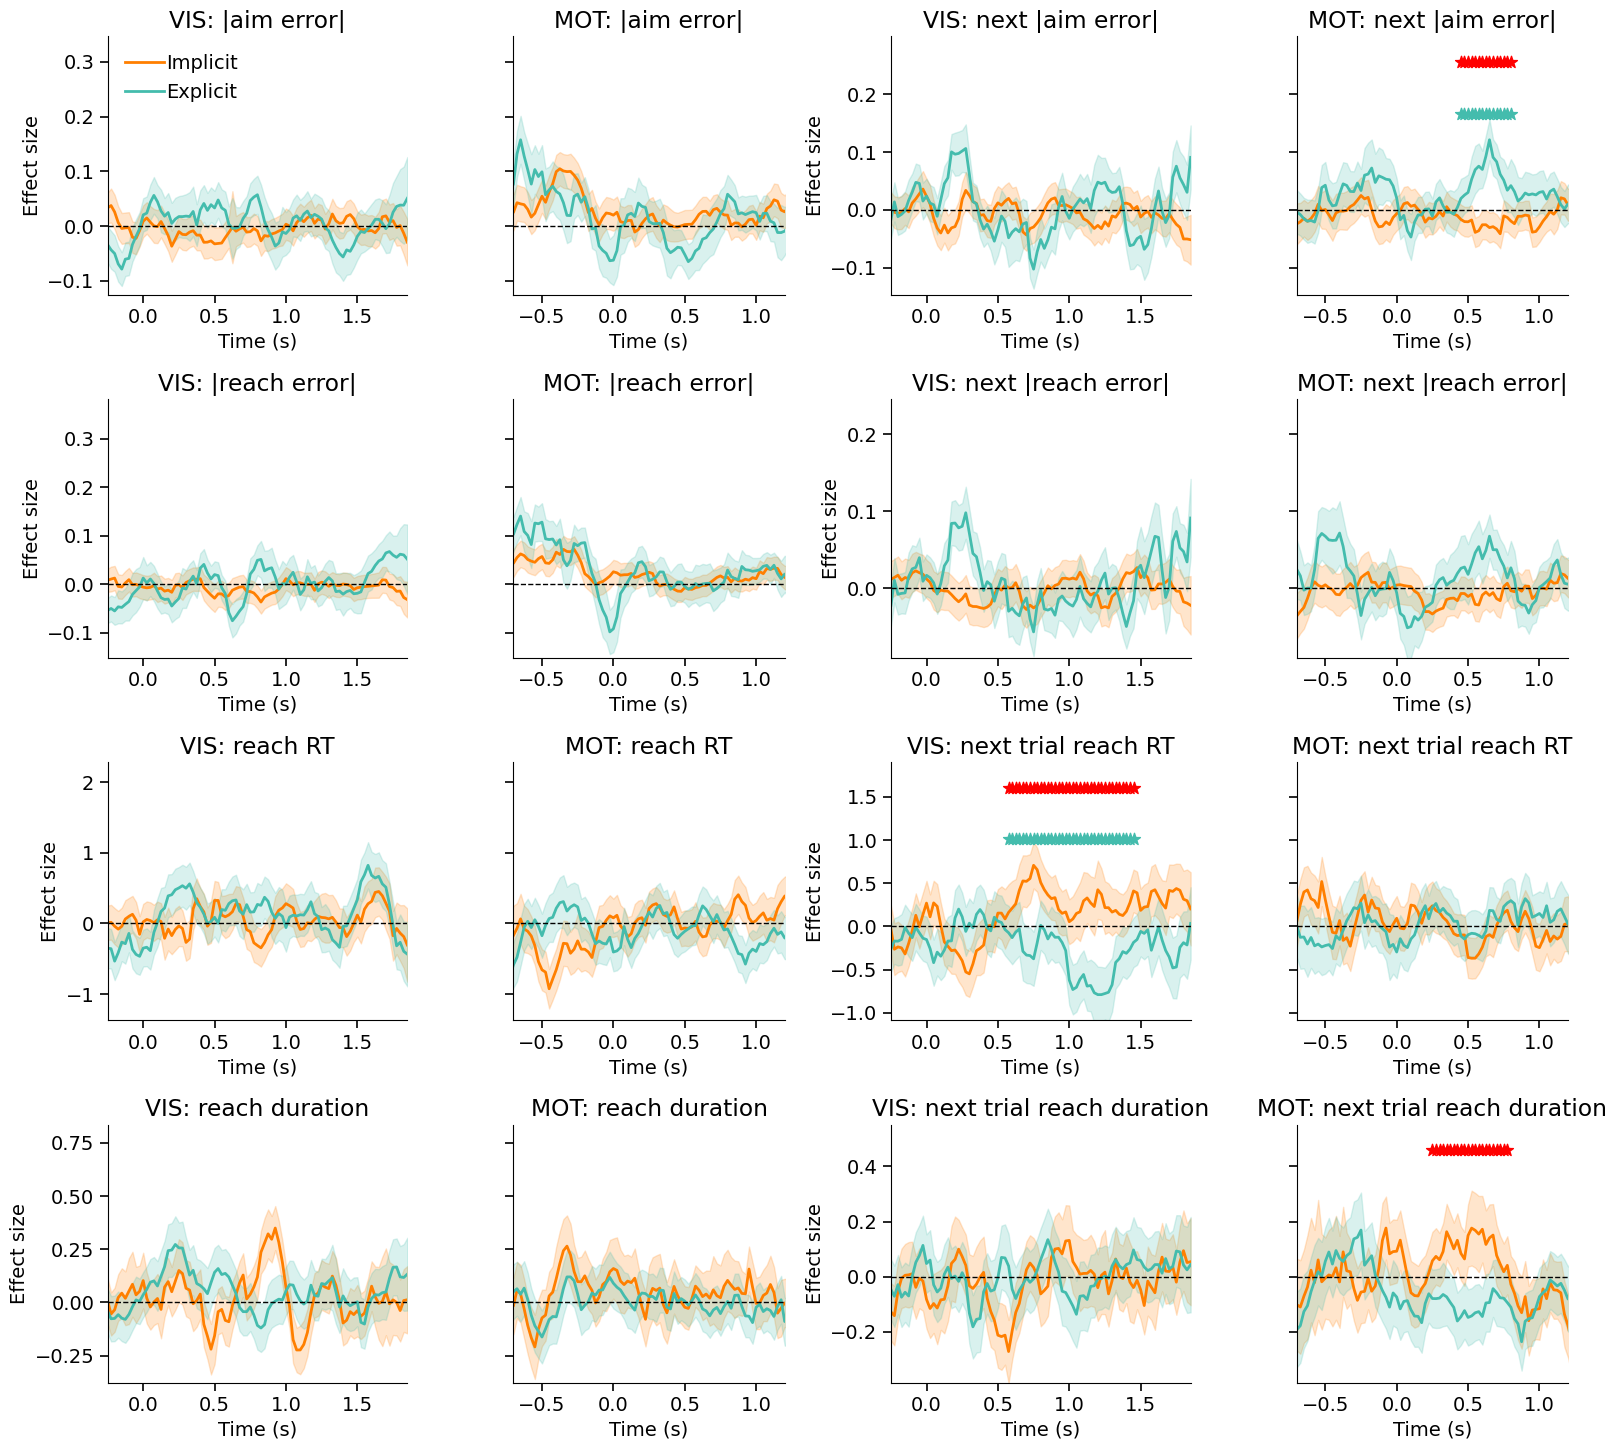

mot PC7 Q2: aim_vis_abs_err ~ mean_burst_count 0.7-1.275s, ChiSq(1)=7.904935369137433, p = 0.0049300102995957
mot PC7 Q2: reach_vis_abs_err ~ mean_burst_count 0.025-1.35s, ChiSq(1)=28.73331154110297, p = 8.306261027447529e-08
vis PC7 Q2: reach_rt_next_trial ~ group:mean_burst_count 1.025-1.45s, ChiSq(1)=6.5745398958083925, p = 0.0103447741537951
                     explicit: z = -2.867783971150311, p = 0.0041335766920063
                     implicit: z = 0.861101795776646, p = 0.3891819802397445
                     explicit - implicit: z = -2.5640865616839834, p = 0.0103447741537951
mot PC7 Q2: reach_dur ~ group:mean_burst_count 0.2-0.7s, ChiSq(1)=7.229627441323591, p = 0.0071710087414287
                     explicit: z = -0.4391021690347404, p = 0.660587507516294
                     implicit: z = 3.4670082722964897, p = 0.0005262856930896657
                     explicit - implicit: z = -2.6887966530259573, p = 0.0071710087414287


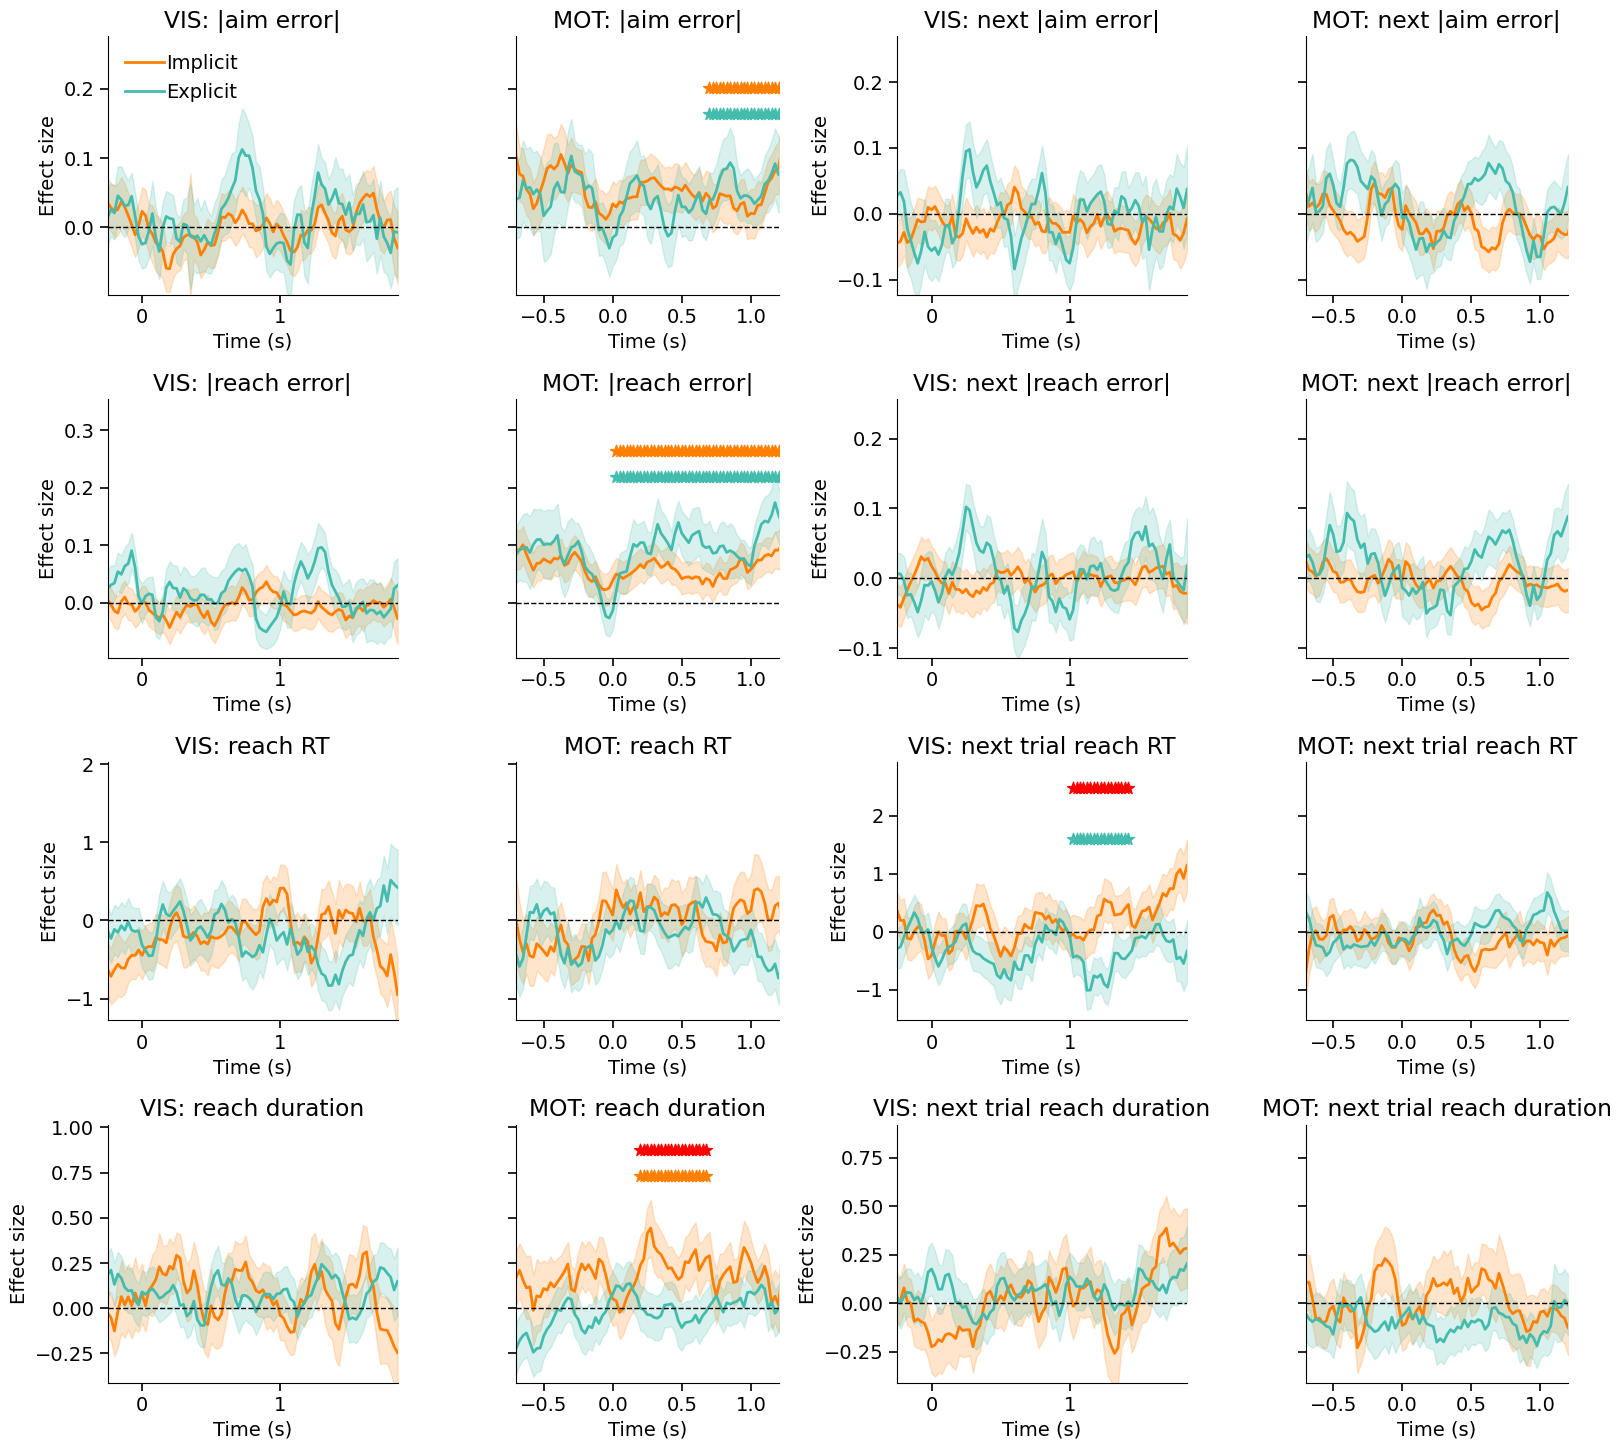

mot PC7 Q3: aim_vis_abs_err ~ mean_burst_count -0.075-1.0s, ChiSq(1)=18.96475184415557, p = 1.33155741847692e-05
mot PC7 Q3: reach_vis_abs_err ~ group:mean_burst_count 0.275-1.15s, ChiSq(1)=9.07368959611276, p = 0.0025931333026661
                     explicit: z = 4.719108971227209, p = 2.368799099108588e-06
                     implicit: z = 2.053634283188188, p = 0.0400111014009312
                     explicit - implicit: z = 3.0122565621329067, p = 0.0025931333026661
mot PC7 Q3: reach_rt ~ group:mean_burst_count -0.525--0.1s, ChiSq(1)=5.412581597974766, p = 0.0199921289745278
                     explicit: z = -1.0558262658442172, p = 0.2910475958324898
                     implicit: z = 2.1070868414062, p = 0.0351100527250966
                     explicit - implicit: z = -2.326495561563522, p = 0.0199921289745278
mot PC7 Q3: reach_dur ~ group:mean_burst_count -0.625--0.275s, ChiSq(1)=3.948068521866828, p = 0.0469251988154872
                     explicit: z = -0.5869913500352179,

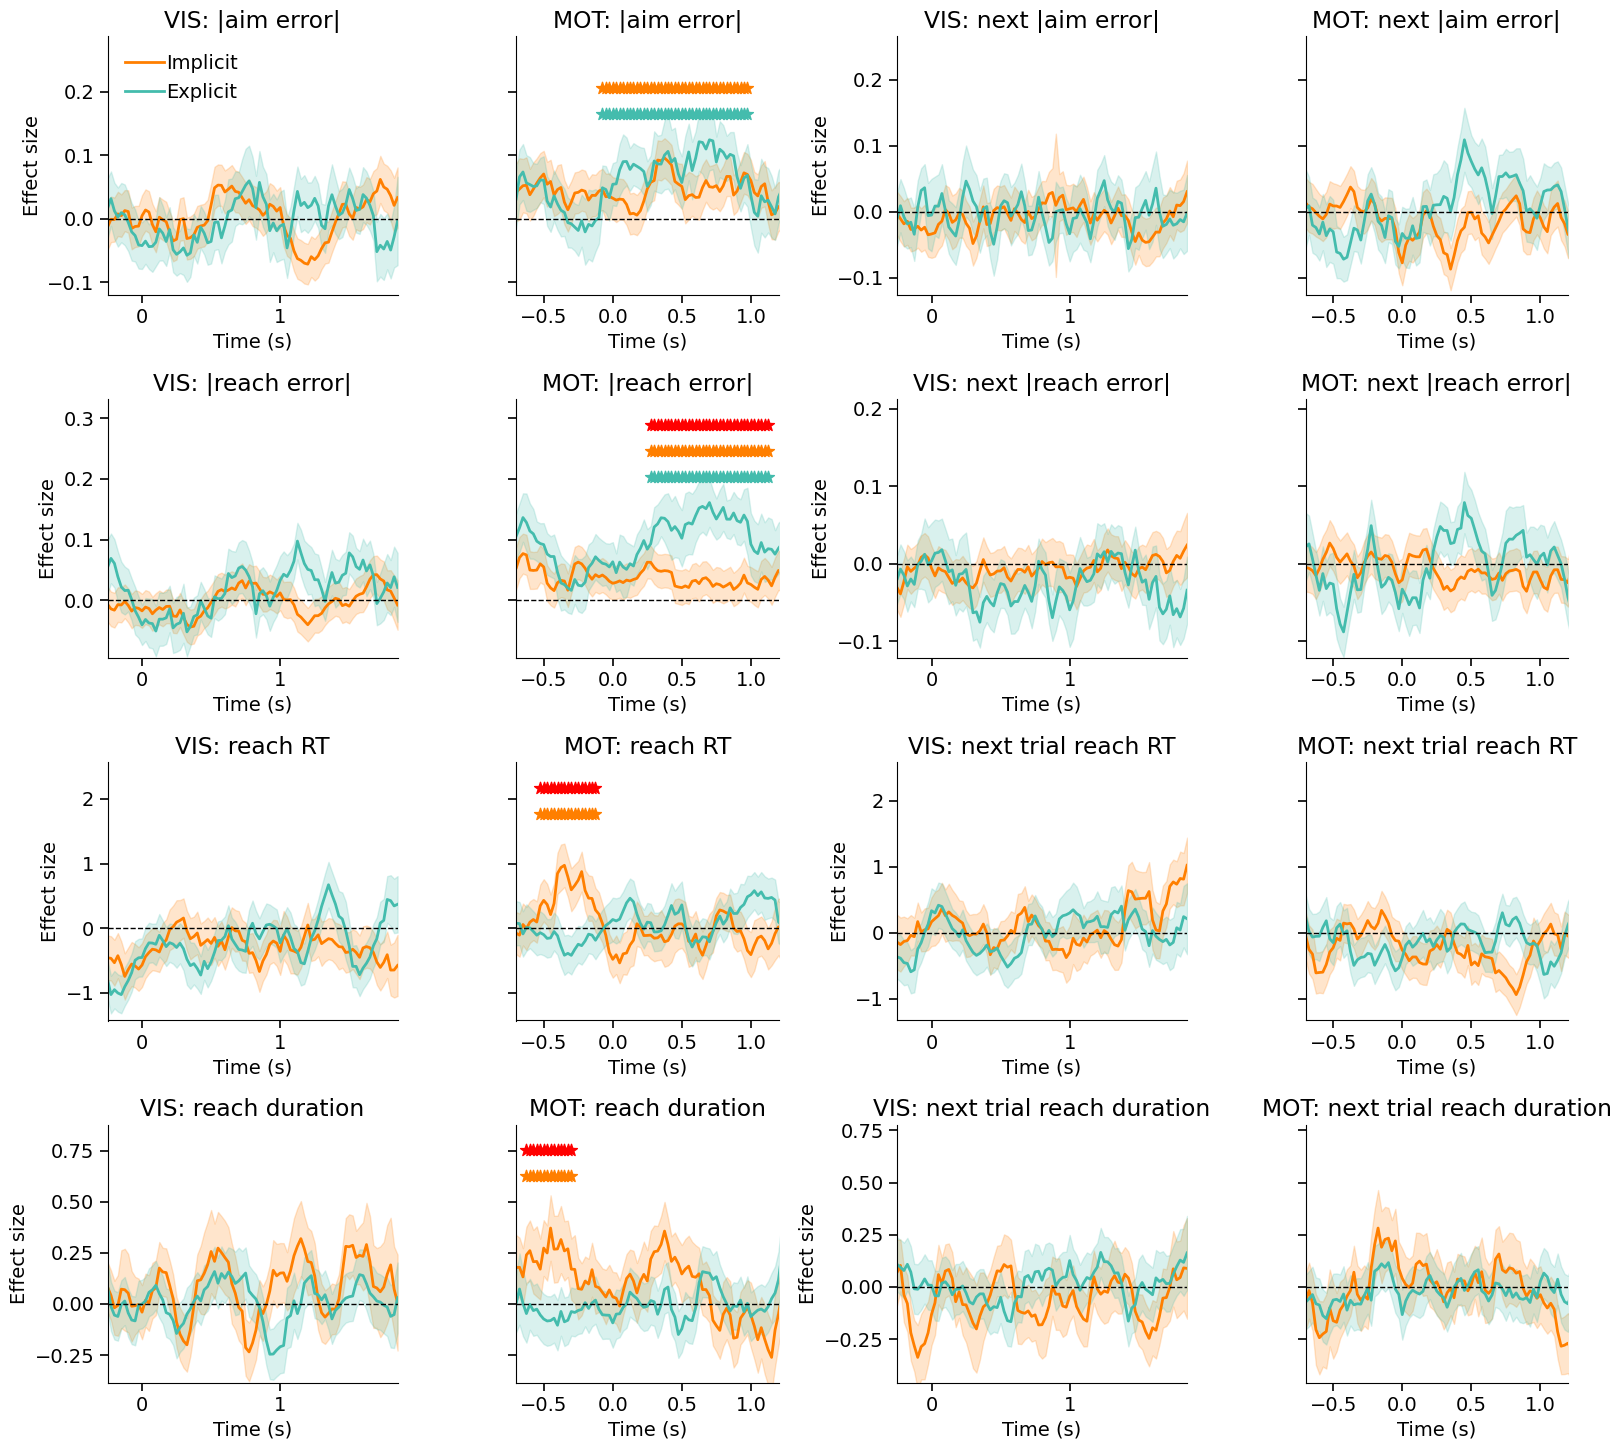

mot PC7 Q4: aim_vis_abs_err ~ mean_burst_count 0.5-1.325s, ChiSq(1)=32.859411124599035, p = 9.907029512075216e-09
mot PC7 Q4: aim_vis_abs_err_next_trial ~ group:mean_burst_count 0.35-0.75s, ChiSq(1)=5.706020707114123, p = 0.016906821430955
                     explicit: z = -2.7266501489645694, p = 0.0063980835797988
                     implicit: z = 0.3200622383644725, p = 0.7489211505431512
                     explicit - implicit: z = -2.388727842830598, p = 0.0169068214309551
mot PC7 Q4: aim_vis_abs_err_next_trial ~ mean_burst_count 0.325-0.775s, ChiSq(1)=3.948572411245178, p = 0.0469111489496116
mot PC7 Q4: reach_vis_abs_err ~ group:mean_burst_count 0.425-1.175s, ChiSq(1)=7.313074941470541, p = 0.006845469054925
                     explicit: z = -5.663571653894755, p = 1.4825422035787504e-08
                     implicit: z = -3.721391786132268, p = 0.00019812776750017703
                     explicit - implicit: z = -2.704269761224005, p = 0.006845469054925
mot PC7 Q4: reach_vi

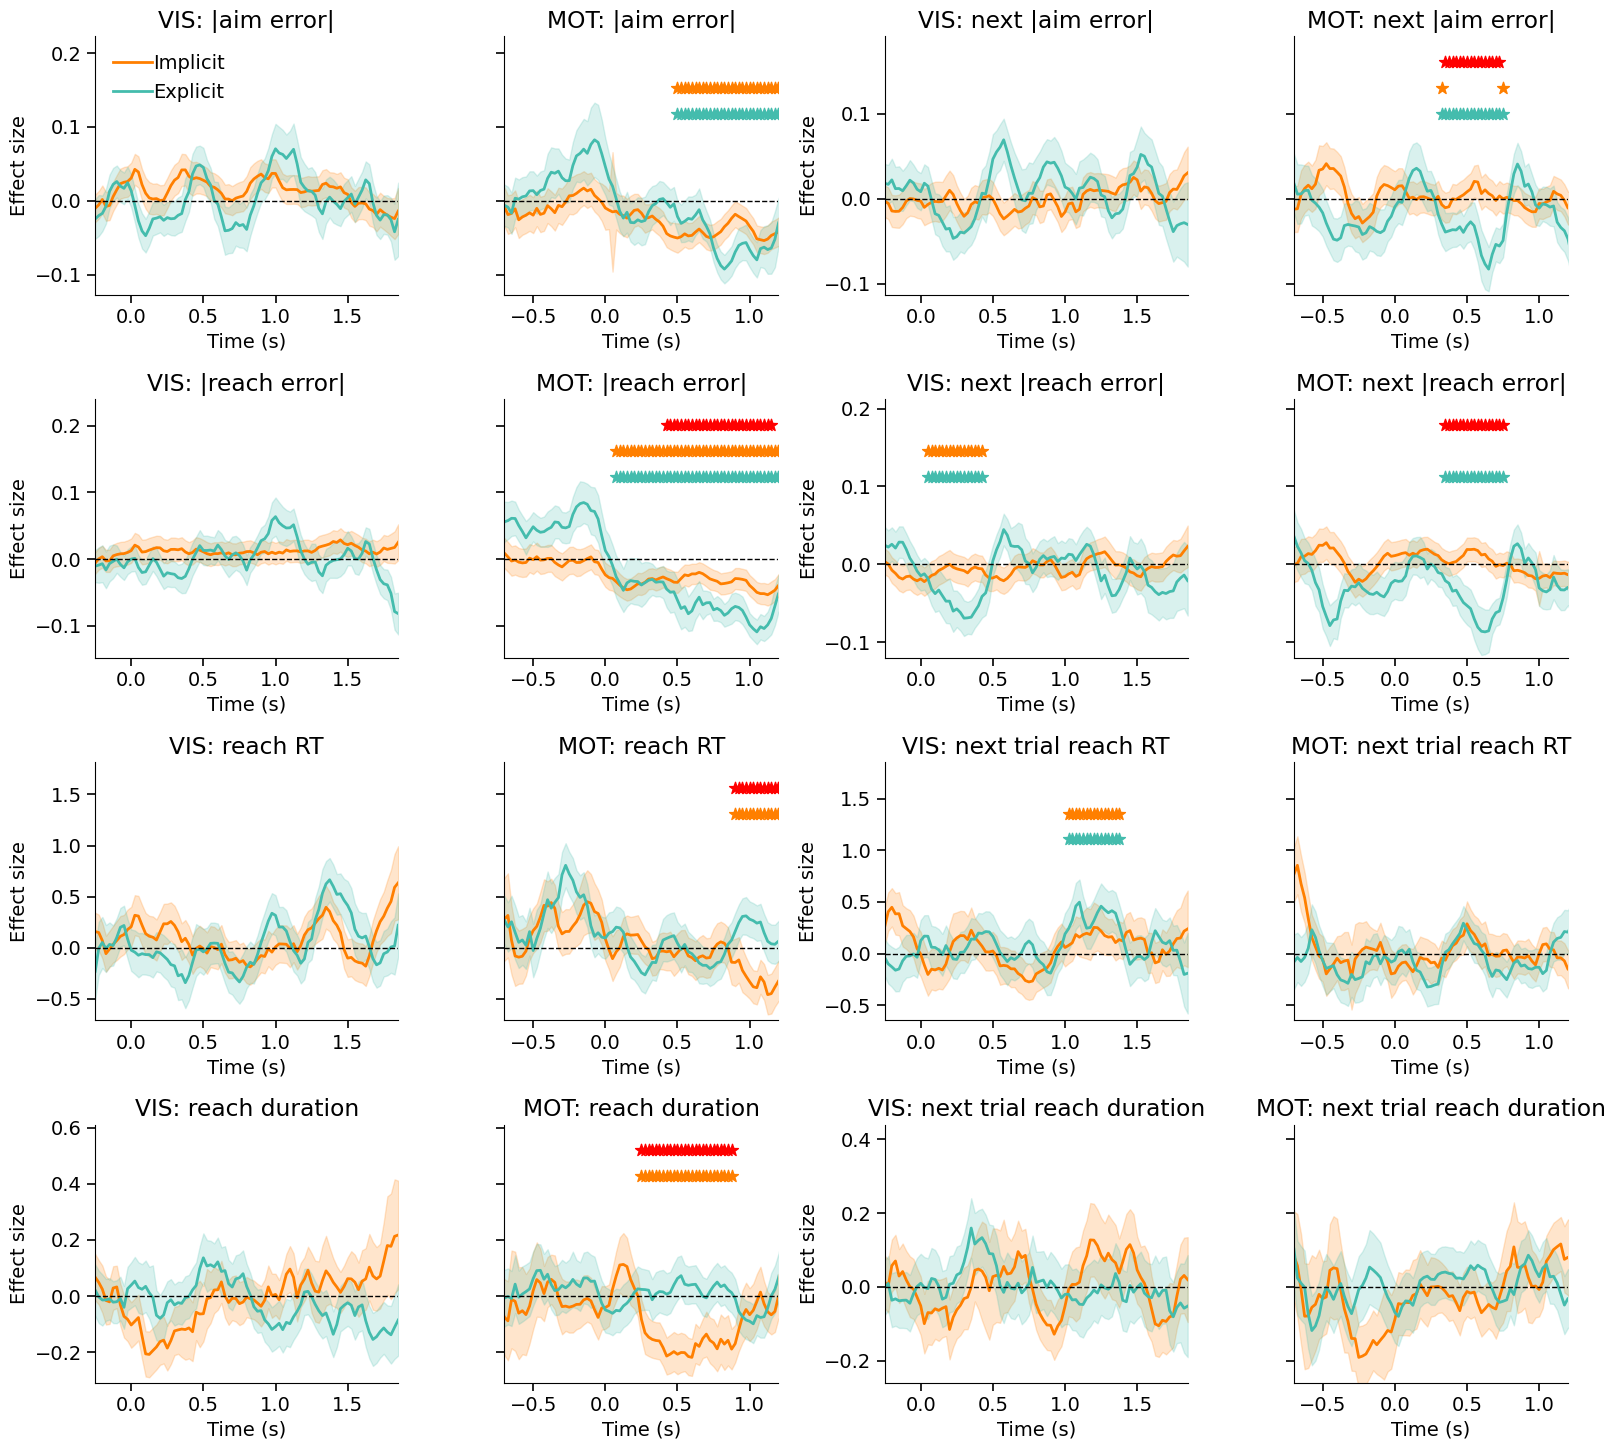

In [16]:
plot_all_vars_per_quartile(var_disp_list)